In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch
from torchvision import transforms
from face_alignment import align
from backbones import get_model
from sklearn.metrics.pairwise import cosine_similarity

e:\synclabs\edgeface\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
torch.cuda.is_available()

True

## MTCNN

In [3]:
import tensorflow as tf

In [5]:
import mtcnn
# from mtcnn.utils.images import load_image
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.patches as patches

In [6]:
from ultralytics import YOLO

In [98]:
detector = mtcnn.MTCNN(device='cpu')
yolo_model = YOLO('models/yolo11n.pt')

In [ ]:
image = load_image('group_test/office2.jpg')

In [99]:
def filter_inside_by_y1_difference(face_boxes, body_boxes):
    """
    Keeps only the best body match per face (lowest y1 difference), from the inside matrix.
    
    Parameters:
        face_boxes: (n, 4) - [x1, y1, w, h]
        body_boxes: (N, 4) - [x1, y1, w, h]
    
    Returns:
        filtered_inside: (n, N) - boolean matrix with only one True per row (or all False)
    """
    face_boxes = np.array(face_boxes, dtype=np.float32)
    body_boxes = np.array(body_boxes, dtype=np.float32)

    n, N = face_boxes.shape[0], body_boxes.shape[0]
    if N == 0:
        return np.zeros((n, 0), dtype=bool)

    # Compute inside matrix
    face_x1y1 = face_boxes[:, :2]
    face_x2y2 = face_boxes[:, :2] + face_boxes[:, 2:]
    body_x1y1 = body_boxes[:, :2]
    body_x2y2 = body_boxes[:, :2] + body_boxes[:, 2:]

    inside = (
        (face_x1y1[:, None, 0] >= body_x1y1[None, :, 0]) &
        (face_x1y1[:, None, 1] >= body_x1y1[None, :, 1]) &
        (face_x2y2[:, None, 0] <= body_x2y2[None, :, 0]) &
        (face_x2y2[:, None, 1] <= body_x2y2[None, :, 1])
    )  # shape (n, N)

    face_y1 = face_x1y1[:, 1][:, None]  # (n, 1)
    body_y1 = body_x1y1[None, :, 1]     # (1, N)
    delta_y1 = face_y1 - body_y1        # (n, N)
    delta_y1[~inside] = np.inf          # ignore invalid matches

    # Find body with min y1 diff per face
    best_body_idx = np.argmin(delta_y1, axis=1)     # (n,)
    min_vals = np.min(delta_y1, axis=1)             # (n,)

    # Create filtered matrix
    filtered_inside = np.zeros_like(inside)
    for i in range(n):
        if min_vals[i] != np.inf:
            filtered_inside[i, best_body_idx[i]] = True

    offset = np.where(np.sum(filtered_inside, axis=1) > 0, 0, -1)
    idxes = np.argmax(filtered_inside, axis=1) + offset
    return idxes


In [100]:


def center_to_topleft(boxes):
    # boxes: (N, 4) -> [x_c, y_c, w, h]
    boxes = boxes.cpu().numpy()
    x1y1 = boxes[:, :2] - boxes[:, 2:] / 2  # x1 = x_c - w/2, y1 = y_c - h/2
    wh = boxes[:, 2:]
    return np.hstack([x1y1, wh])  # (N, 4) -> [x1, y1, w, h]

def assign_colors(num_colors):
    return np.random.rand(num_colors, 3)
    

def draw_boxes(image, results: list, boxes):
    fig, ax = plt.subplots(1)
    ax.imshow(image)

    face_boxes = []
    for result in results:
        x, y, w, h = result['box']
        face_boxes.append([x, y, w, h])
    face_boxes = np.array(face_boxes, dtype=np.float32)
    n = len(face_boxes)

    # Convert YOLO boxes to top-left format
    if boxes is not None and len(boxes) > 0:
        body_boxes = center_to_topleft(boxes)
        idxes = filter_inside_by_y1_difference(face_boxes, body_boxes)
        print("Matched face→body:", idxes)

        # Build reverse mapping: body → face
        body_to_face = {}
        matched_faces = []
        for face_idx, body_idx in enumerate(idxes):
            if body_idx != -1:
                body_to_face[body_idx] = face_idx
                matched_faces.append(face_idx)

        # Assign colors only to matched faces
        colors = assign_colors(len(matched_faces))
        face_to_color = {face_idx: colors[i] for i, face_idx in enumerate(matched_faces)}

    else:
        body_boxes = np.empty((0, 4), dtype=np.float32)
        idxes = np.full(n, -1, dtype=int)
        body_to_face = {}
        face_to_color = {}

    # Draw faces
    for i, (x, y, w, h) in enumerate(face_boxes):
        color = face_to_color.get(i, 'black')
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)

    # Draw body boxes
    for i, (x, y, w, h) in enumerate(body_boxes):
        face_idx = body_to_face.get(i, None)
        color = face_to_color.get(face_idx, 'black') if face_idx is not None else 'black'
        rect = patches.Rectangle((x, y), w, h, linewidth=1, linestyle='dashed', edgecolor=color, facecolor='none')
        ax.add_patch(rect)

    plt.axis('off')
    plt.show()
    return idxes


def get_bboxes(image,  person_class = 0):
    results = yolo_model(image)
    idxes = torch.where(results[0].boxes.cls == person_class)
    bboxes = results[0].boxes.xywh[idxes]
    return bboxes



In [101]:
def filter_matched_faces(face_boxes, idxes):
    """
    Remove unmatched face boxes (where idx == -1)

    Parameters:
        face_boxes: (n, 4) np.array
        idxes: (n,) np.array of int (face → body index), with -1 for unmatched

    Returns:
        matched_face_boxes: (n', 4)
        matched_idxes: (n',)
    """
    face_boxes = np.array(face_boxes)
    idxes = np.array(idxes)

    mask = idxes != -1  # keep only matched faces
    matched_face_boxes = face_boxes[mask]
    matched_idxes = idxes[mask]

    return matched_face_boxes, matched_idxes


In [102]:
def get_face_body_matches(results: list, boxes):
    """
    Extract face/body boxes and match face to body by vertical alignment and containment.

    Parameters:
        results: list of face detection dicts with 'box': [x1, y1, w, h]
        boxes: tensor or array of YOLO-style boxes [x_c, y_c, w, h]

    Returns:
        face_boxes: (n, 4) np.array of [x1, y1, w, h]
        body_boxes: (N, 4) np.array of [x1, y1, w, h]
        face_to_body_idx: (n,) np.array of body indices matched to each face (or -1)
    """
    # Convert face boxes
    face_boxes = np.array([result['box'] for result in results], dtype=np.float32)

    # Convert YOLO boxes to top-left format
    if boxes is not None and len(boxes) > 0:
        body_boxes = center_to_topleft(boxes)
        face_to_body_idx = filter_inside_by_y1_difference(face_boxes, body_boxes)
        face_boxes, face_to_body_idx = filter_matched_faces(face_boxes, face_to_body_idx)
    else:
        body_boxes = np.empty((0, 4), dtype=np.float32)
        face_to_body_idx = np.full(len(face_boxes), -1, dtype=int)

    return face_boxes, body_boxes, face_to_body_idx


In [7]:
model_name = 'edgeface_xs_gamma_06'
checkpoint_folder = 'checkpoints'
model = get_model(model_name)
checkpoint_path = os.path.join(checkpoint_folder, f"{model_name}.pt")
model.load_state_dict(torch.load(checkpoint_path, map_location='cpu'))
model.eval()

TimmFRWrapperV2(
  (model): EdgeNeXt(
    (stem): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((32,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): EdgeNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvBlock(
            (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32)
            (norm): LayerNorm((32,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): LoRaLin(
                (linear1): Linear(in_features=32, out_features=19, bias=False)
                (linear2): Linear(in_features=19, out_features=128, bias=True)
              )
              (act): GELU(approximate='none')
              (drop1): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (fc2): LoRaLin(
                (linear1): Linear(in_features=128, out_features=19, bias=False)
                (linea

In [8]:
import os
import torch
from torchvision import transforms
from PIL import Image
from face_alignment import align
from backbones import get_model

def generate_face_embeddings(folder_path, model_name="edgeface_xs_gamma_06", checkpoint_folder="checkpoints"):
    # Load model
    model = get_model(model_name)
    checkpoint_path = os.path.join(checkpoint_folder, f"{model_name}.pt")
    model.load_state_dict(torch.load(checkpoint_path, map_location='cpu'))
    model.eval()

    # Preprocessing transform
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
    ])

    embeddings = []
    names = []

    for file in sorted(os.listdir(folder_path)):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            name = os.path.splitext(file)[0]
            image_path = os.path.join(folder_path, file)

            try:
                # Align face
                aligned = align.get_aligned_face(image_path)
                if aligned is None:
                    print(f"Warning: Could not align {file}")
                    continue
                # Show aligned face
                plt.imshow(aligned)
                plt.title(f"Aligned: {name}")
                plt.axis('off')
                plt.show()

                # Preprocess and extract embedding
                input_tensor = transform(aligned).unsqueeze(0)  # Add batch dim
                with torch.no_grad():
                    embedding = model(input_tensor).squeeze().cpu().numpy()
                
                embeddings.append(embedding)
                names.append(name)
            except Exception as e:
                print(f"Error processing {file}: {e}")
    embeddings = np.array(embeddings)

    return embeddings, names


In [9]:
from torchvision.transforms import functional as F
from PIL import Image
import numpy as np
import torch

def get_face_embeddings_from_image(image, face_boxes, model, device='cpu'):
    """
    Crop, resize, transform, and embed each face in the image.
    
    Args:
        image: PIL.Image or np.array (H, W, 3)
        face_boxes: (n, 4) - [x1, y1, w, h]
        model: embedding model
        transform: preprocessing function
        device: 'cpu' or 'cuda'
    
    Returns:
        face_embeddings: (n, 512) tensor
    """

    transform = transforms.Compose([
        transforms.Resize((112, 112)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
    ])
    
    if isinstance(image, np.ndarray):
        image = Image.fromarray(image.astype(np.uint8))

    face_tensors = []
    for x, y, w, h in face_boxes:
        face = image.crop((x, y, x + w, y + h))
        face_tensor = transform(face)
        face_tensors.append(face_tensor)

    face_batch = torch.stack(face_tensors).to(device)

    with torch.no_grad():
        embeddings = model(face_batch)  # shape: (n, 512)

    return embeddings


e:\synclabs\edgeface\face_alignment\mtcnn_pytorch\src\matlab_cp2tform.py:90: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  r, _, _, _ = lstsq(X, U)


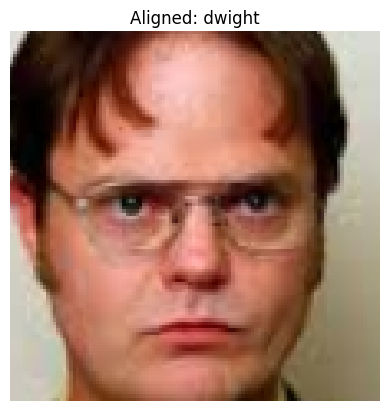

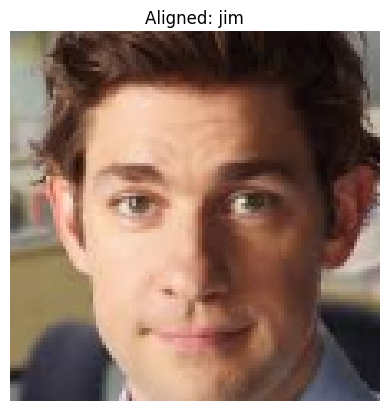

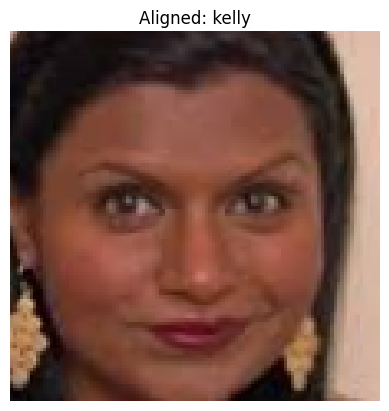

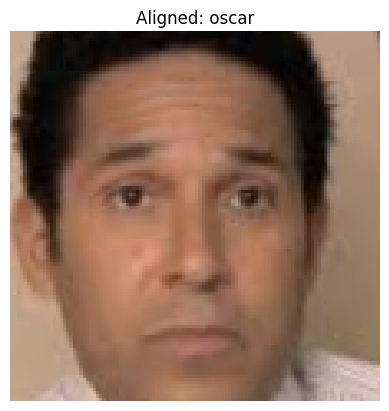

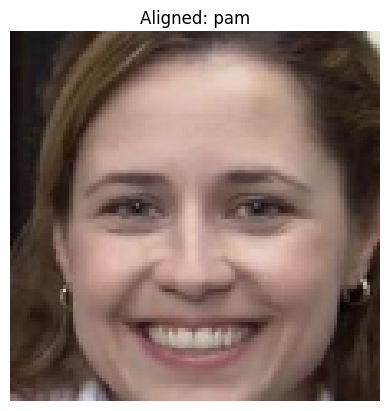

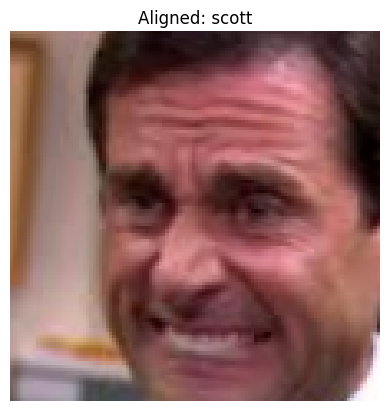

In [10]:
source_emb, name = generate_face_embeddings('faces')

In [18]:
from face_alignment import align
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import torch.nn.functional as F
from torchvision import transforms

In [29]:
def recognize_faces_from_aligned(
    img_path: str,
    model,
    transform,
    source_embeddings: np.ndarray,
    names: list,
    align,
    threshold: float = 0.5
):
    """
    Recognize and label faces in an image using aligned face crops.

    Args:
        img_path: Path to group image
        model: PyTorch embedding model
        transform: Transform to preprocess 112x112 face crops
        source_embeddings: (k, 512) numpy array of known face embeddings
        names: list of length k, names of known identities
        align: object with get_aligned_faces() method (returns bboxes, [aligned PIL faces])
        threshold: cosine similarity threshold to consider a match

    Returns:
        PIL.Image with annotated face boxes and names
    """
    # Load original image
    image = Image.open(img_path).convert("RGB")
    bboxes, aligned_faces = align.get_aligned_faces(img_path)

    if not aligned_faces:
        print("No faces detected.")
        return image

    model.eval()
    embeddings = []

    for face in aligned_faces:
        tensor = transform(face).unsqueeze(0)  # [1, 3, 112, 112]
        with torch.no_grad():
            emb = model(tensor).squeeze(0).cpu()
            embeddings.append(emb)

    embeddings = torch.stack(embeddings)                      # (n, 512)
    src_embeddings = torch.tensor(source_embeddings)          # (k, 512)

    # Compute cosine similarity matrix: (n, k)
    cos_sim = F.cosine_similarity(embeddings[:, None, :], src_embeddings[None, :, :], dim=-1)

    # Get best match per face
    best_sim, best_idx = torch.max(cos_sim, dim=1)  # (n,)
    is_match = best_sim >= threshold                # (n,) mask

    # Draw boxes and labels
    draw = ImageDraw.Draw(image)
    font = ImageFont.load_default()

    for i, box in enumerate(bboxes):
        x, y, x2, y2, _ = map(int, box)

        if is_match[i]:
            name = names[best_idx[i]]
            label = f"{name} ({best_sim[i]:.2f})"
            color = "lime"
        else:
            label = "Unknown"
            color = "red"

        draw.rectangle([x, y, x2, y2], outline=color, width=2)
        draw.text((x, y - 10), label, fill="white", font=font)

    # Show result
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis('off')
    plt.title("Face Recognition Results")
    plt.show()

    return image

In [39]:
img_path = "group_test/office4.jpg"
image = Image.open(img_path).convert("RGB")
bboxes, faces = align.get_aligned_faces(img_path)

e:\synclabs\edgeface\face_alignment\mtcnn_pytorch\src\matlab_cp2tform.py:90: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  r, _, _, _ = lstsq(X, U)


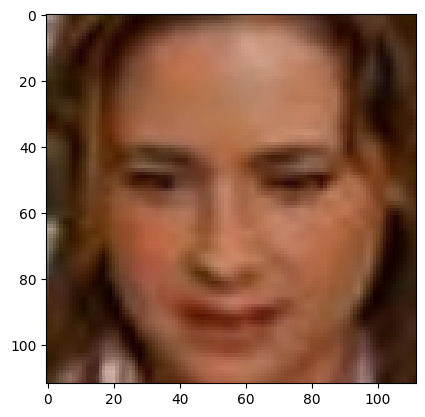

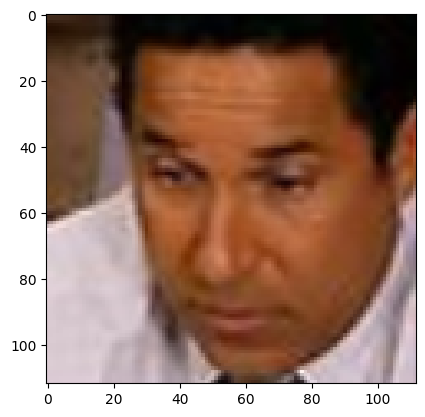

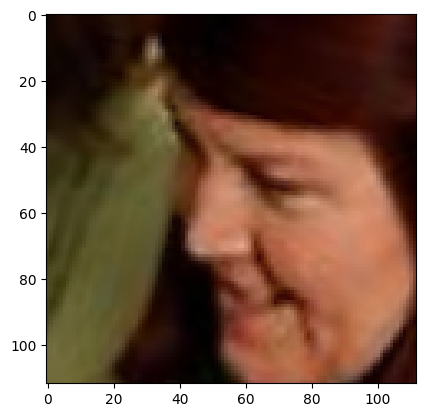

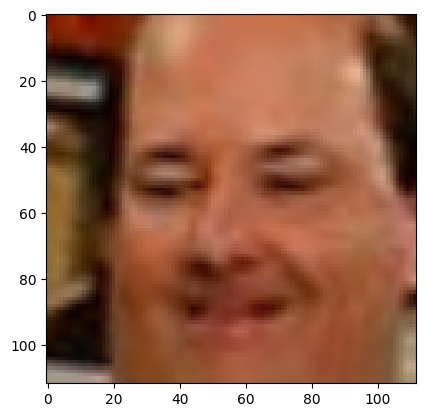

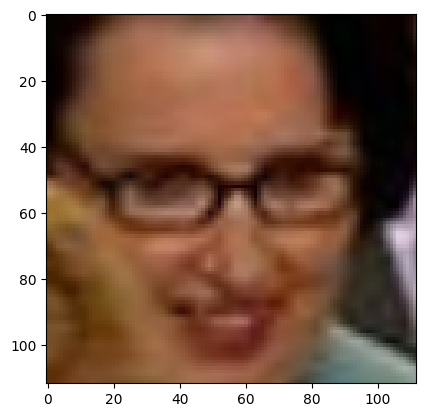

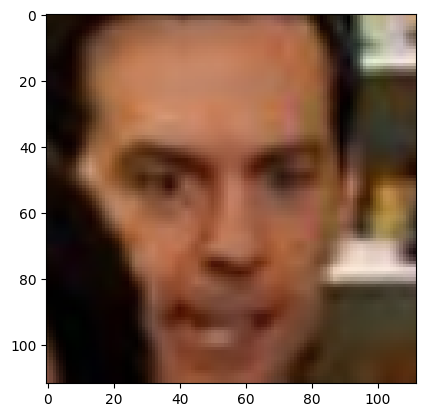

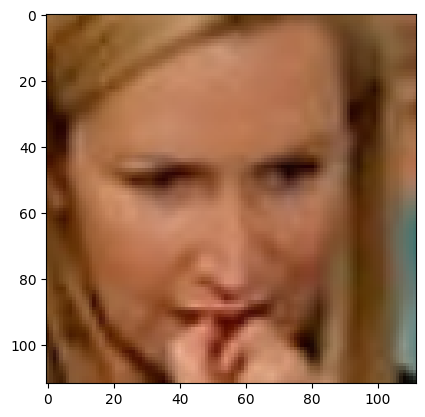

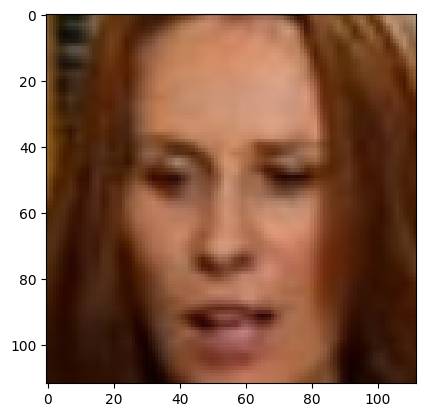

In [40]:
for face in faces:
    plt.imshow(face)
    plt.show()


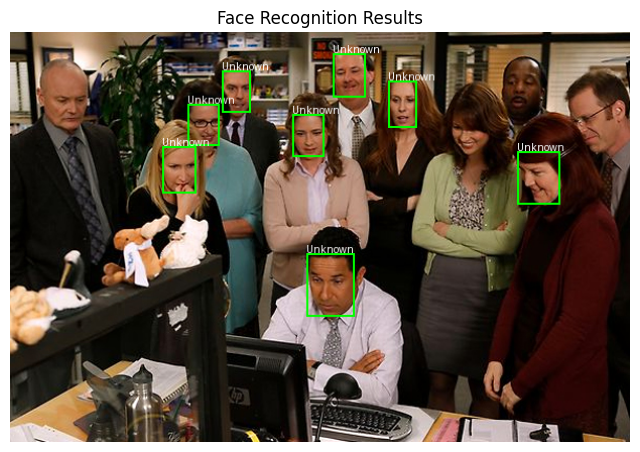

In [41]:
draw = ImageDraw.Draw(image)
font = ImageFont.load_default()
for i, box in enumerate(bboxes):
    x, y, x2, y2, _ = map(int, box)   
    color = "lime"
    label = "Unknown"
    draw.rectangle([x, y, x2, y2], outline=color, width=2)
    draw.text((x, y - 10), label, fill="white", font=font)

# Show result
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis('off')
plt.title("Face Recognition Results")
plt.show()

In [30]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

e:\synclabs\edgeface\face_alignment\mtcnn_pytorch\src\matlab_cp2tform.py:90: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  r, _, _, _ = lstsq(X, U)


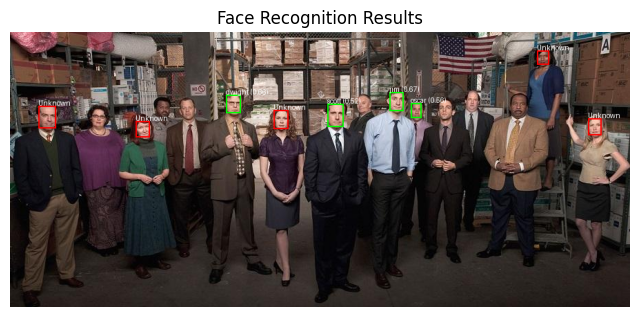

In [31]:


_ = recognize_faces_from_aligned(
    img_path="group_test/office1.jpg",
    model=model,
    transform=transform,
    source_embeddings=source_emb,  # shape: (k, 512)
    names=name,               # length: k
    align=align,                   # align.get_aligned_faces must return (bboxes, faces)
    threshold=0.5)

In [16]:
len(faces)

9

[<PIL.Image.Image image mode=RGB size=112x112>]

In [68]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_matched_faces(image, face_boxes, similarity_matrix, known_names, threshold=0.6):
    """
    Draws face boxes on the image with predicted names.
    
    Args:
        image: np.array or PIL.Image
        face_boxes: (n, 4) array
        similarity_matrix: (k, n) tensor of cosine similarities
        known_names: list of k names
        threshold: minimum similarity to accept match
    """
    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0).numpy()
    if isinstance(image, np.ndarray):
        image = Image.fromarray(image.astype(np.uint8))

    fig, ax = plt.subplots(1)
    ax.imshow(image)

    k, n = similarity_matrix.shape
    sim_np = similarity_matrix.cpu().numpy()
    best_matches = np.argmax(sim_np, axis=0)      # (n,)
    best_scores = np.max(sim_np, axis=0)          # (n,)

    for i, (x, y, w, h) in enumerate(face_boxes):
        name = known_names[best_matches[i]] if best_scores[i] >= threshold else "Unknown"
        color = 'green' if name != "Unknown" else 'red'
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x + w/2, y - 5, f"{name}", color=color, fontsize=10, ha='center')

    plt.axis('off')
    plt.show()


In [69]:
import torch.nn.functional as F

def compute_similarity_matrix(known_embeddings, face_embeddings):
    """
    Computes cosine similarity matrix between known and detected embeddings.
    
    Args:
        known_embeddings: (k, 512) tensor
        face_embeddings: (n, 512) tensor
    
    Returns:
        similarity_matrix: (k, n) tensor
    """
    # Normalize to unit vectors
    known_norm = F.normalize(known_embeddings, dim=1)
    face_norm = F.normalize(face_embeddings, dim=1)

    # Cosine similarity: dot product between each known and detected face
    similarity = torch.matmul(known_norm, face_norm.T)  # shape: (k, n)
    return similarity


In [83]:
f_b.shape

(12, 4)

In [84]:
import numpy as np

def adjust_mtcnn_boxes(boxes, image_shape, margin_ratio=0.2, square=True):
    """
    Vectorized version to adjust multiple MTCNN boxes.

    Args:
        boxes: (n, 4) array of [x, y, w, h]
        image_shape: (H, W, C)
        margin_ratio: float
        square: bool

    Returns:
        adjusted_boxes: (n, 4) array of [x1, y1, w, h]
    """
    # boxes = np.array(boxes, dtype=np.float32)
    H, W = image_shape[:2]

    x, y, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    cx, cy = x + w / 2, y + h / 2

    if square:
        size = np.maximum(w, h) * (1 + margin_ratio)
        w_new = h_new = size
    else:
        w_new = w * (1 + margin_ratio)
        h_new = h * (1 + margin_ratio)

    x1 = np.clip(cx - w_new / 2, 0, W)
    y1 = np.clip(cy - h_new / 2, 0, H)
    x2 = np.clip(cx + w_new / 2, 0, W)
    y2 = np.clip(cy + h_new / 2, 0, H)

    new_w = x2 - x1
    new_h = y2 - y1

    adjusted = np.stack([x1, y1, new_w, new_h], axis=1)
    return adjusted.astype(np.int32)



0: 448x640 13 persons, 5 ties, 1 bottle, 1 chair, 1 potted plant, 2 laptops, 22.5ms
Speed: 8.4ms preprocess, 22.5ms inference, 6.1ms postprocess per image at shape (1, 3, 448, 640)


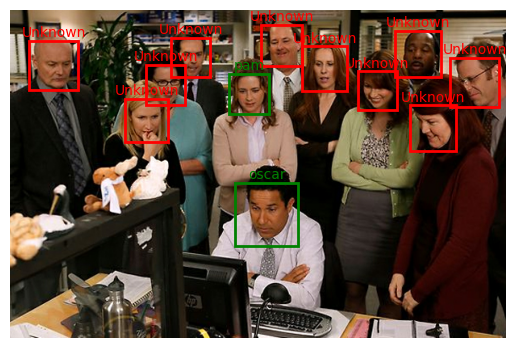

In [85]:
img_path = 'group_test/office4.jpg'
image = load_image(img_path)
result = detector.detect_faces(image)
bboxes = get_bboxes(image)
f_b, bb, idxes = get_face_body_matches(result, bboxes)
f_b = adjust_mtcnn_boxes(f_b, image.shape )
image_embeddings = get_face_embeddings_from_image(image,f_b, model)
sim = compute_similarity_matrix(torch.tensor(source_emb), image_embeddings)
draw_matched_faces(image, f_b, sim, name, threshold=0.4)
## check the results


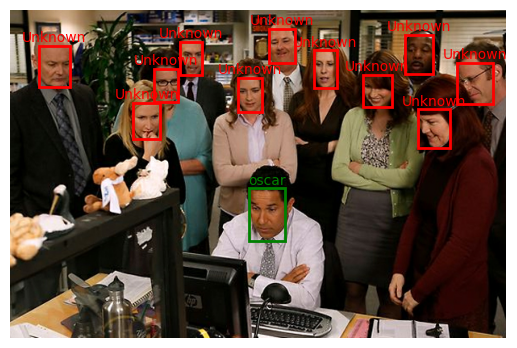

In [66]:
draw_matched_faces(image, f_b, sim, name, threshold=0.4)

In [32]:
import glob
import os
image_folder = 'group_test'
extensions = ['*.jpeg', '*.jpg', '*.png']

image_paths = []
for ext in extensions:
    image_paths.extend(glob.glob(os.path.join(image_folder, ext)))



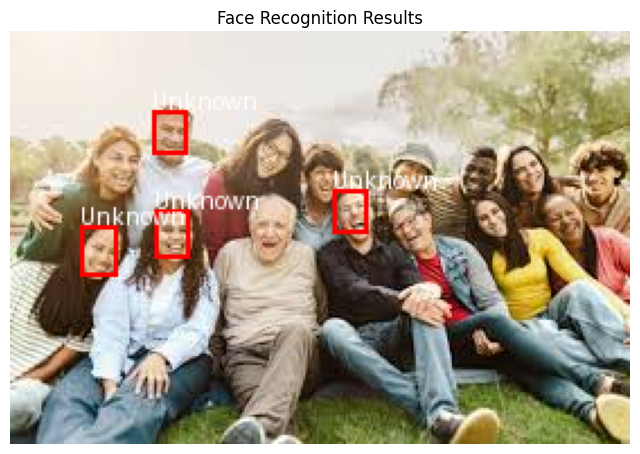

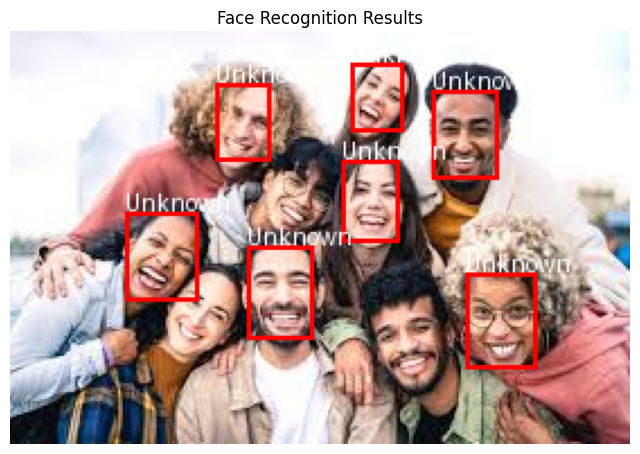

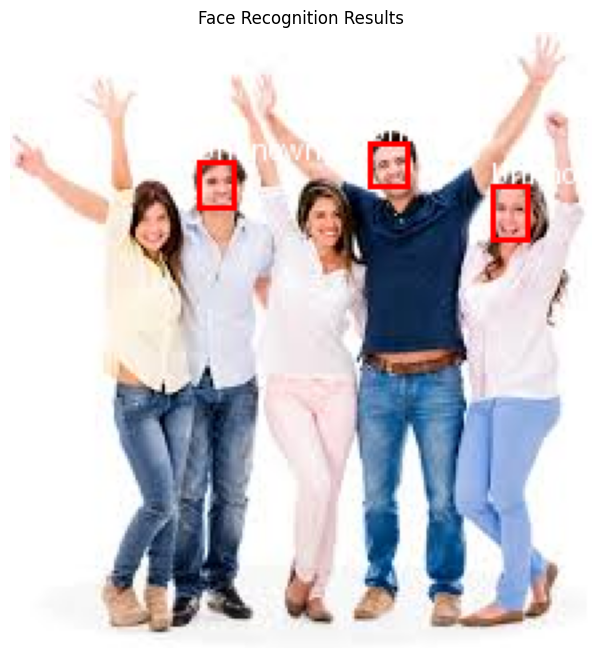

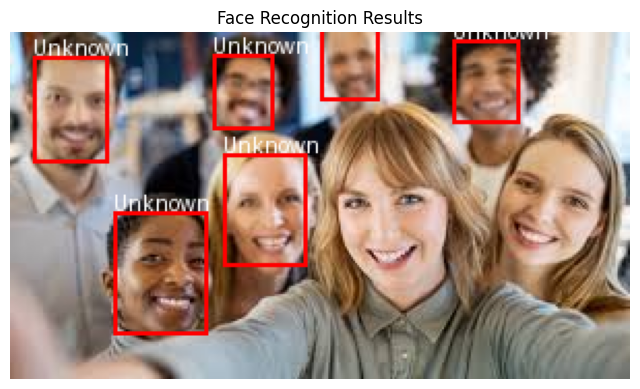

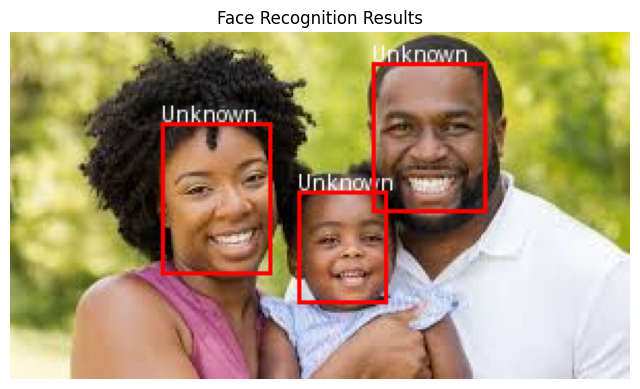

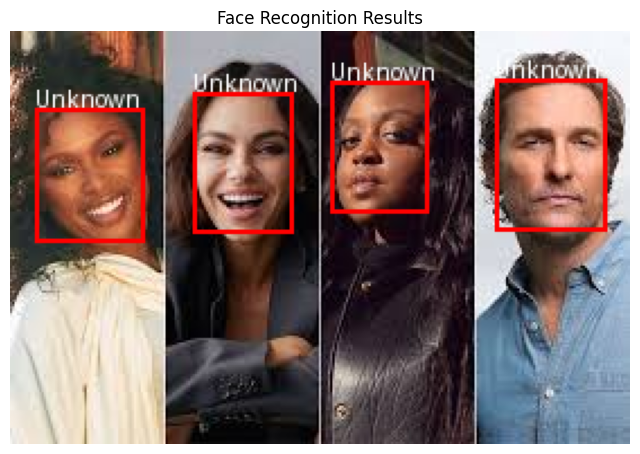

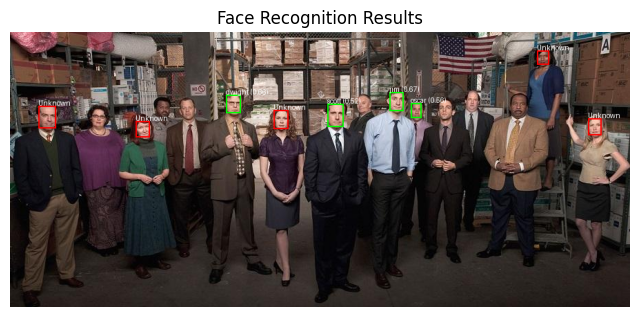

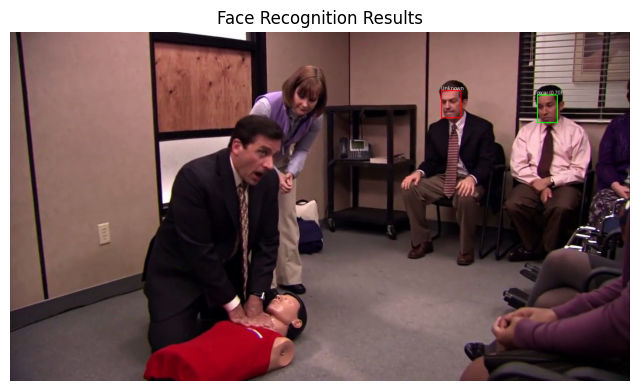

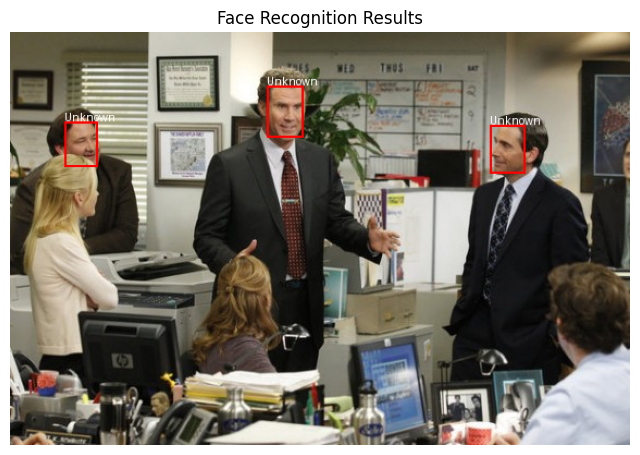

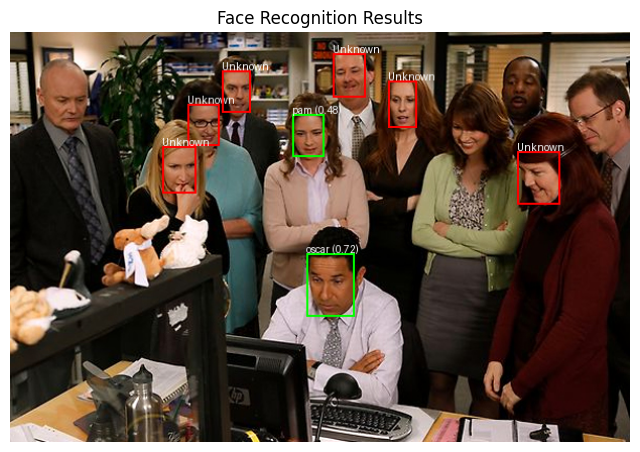

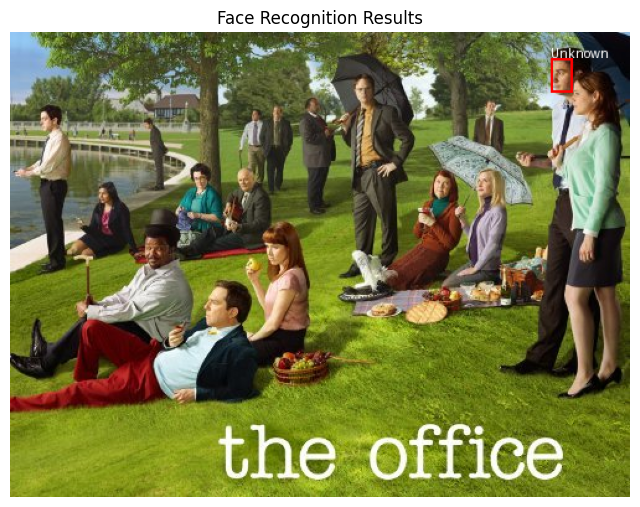

In [33]:

for img_path in image_paths:
    _ = recognize_faces_from_aligned(
    img_path=img_path,
    model=model,
    transform=transform,
    source_embeddings=source_emb,  # shape: (k, 512)
    names=name,               # length: k
    align=align,                   # align.get_aligned_faces must return (bboxes, faces)
    threshold=0.4)

# OLD

In [ ]:
# load model
model_name="edgeface_xs_gamma_06" # or edgeface_xs_gamma_06
model=get_model(model_name)
checkpoint_path=f'checkpoints/{model_name}.pt'
model.load_state_dict(torch.load(checkpoint_path, map_location='cuda'))

transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
            ])

In [ ]:
from PIL import Image
img = Image.open("new_test/rajnish1.JPG")
img.save("new_test/rajnish1_fixed.JPG") 

In [ ]:
img1_path = r"new_test\rajnish1_new.JPG"
img2_path =  r"new_test\rajnish1_cropped.JPG"

In [ ]:
aligned = align.get_aligned_face(img1_path) # align face
transformed_input1 = transform(aligned)
aligned = align.get_aligned_face(img2_path) # align face
transformed_input2 = transform(aligned)

In [ ]:
# Convert the tensor to a numpy array and transpose to (H, W, C) for imshow
img_np = transformed_input2.permute(1, 2, 0).cpu().numpy()
# Undo normalization for display: x = x * std + mean
img_np = (img_np * 0.5) + 0.5
img_np = np.clip(img_np, 0, 1)
plt.imshow(img_np)
plt.axis('off')
plt.show()

In [ ]:
# Convert the tensor to a numpy array and transpose to (H, W, C) for imshow
img_np = transformed_input1.permute(1, 2, 0).cpu().numpy()
# Undo normalization for display: x = x * std + mean
img_np = (img_np * 0.5) + 0.5
img_np = np.clip(img_np, 0, 1)
plt.imshow(img_np)
plt.axis('off')
plt.show()

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

In [ ]:
def read_face_pairs(file_path):
    pairs = []
    labels = []
    
    with open(file_path, 'r') as file:
        for line in file:
            parts = line.strip().split('\t')
            if len(parts) == 3:
                # Same person, positive pair (1)
                person, idx1, idx2 = parts
                idx1 = int(idx1)
                idx2 = int(idx2)
                pairs.append((f"{person}_{idx1:04d}", f"{person}_{idx2:04d}"))
                labels.append(1)
            elif len(parts) == 4:
                # Different people, negative pair (0)
                person1, idx1, person2, idx2 = parts
                idx1 = int(idx1)
                idx2 = int(idx2)
                pairs.append((f"{person1}_{idx1:04d}", f"{person2}_{idx2:04d}"))
                labels.append(0)
    
    return pairs, labels

# Function to load an image given the person and index
def load_image(person, idx, lfw_funneled_dir):
    image_path = os.path.join(lfw_funneled_dir, person, f"{person}_{int(idx):04d}.jpg")
    if os.path.exists(image_path):
        # Return the path if the image exists
        return image_path
    else:
        raise FileNotFoundError(f"Image not found: {image_path}")

In [ ]:
# Convert the image path into an actual image and preprocess it
def get_embeddings(image_path):
    try:
        # Load the image using PIL (or OpenCV)
     
        aligned = align.get_aligned_face(image_path)  # Assuming `align.get_aligned_face` works with PIL image
        transformed_input = transform(aligned)  # Apply the necessary transformations (e.g., normalization)
        transformed_input = transformed_input.unsqueeze(0)  # Add batch dimension
        transformed_input = transformed_input.to(device)  
        embedding = model(transformed_input)  # Get the embedding from your model
        return embedding
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None  # Return None if there's any issue

# Calculate cosine similarity using PyTorch's built-in function
def get_similarity(embedding1, embedding2):
    # Ensure embeddings are on CPU for cosine similarity
    embedding1 = embedding1.cpu()
    embedding2 = embedding2.cpu()
    
    # Normalize the embeddings (unit vectors) before calculating cosine similarity
    similarity = torch.nn.functional.cosine_similarity(embedding1, embedding2)
    return similarity.item()

# Function to evaluate the LFW dataset using pairs
def evaluate_lfw(pair_file_path, lfw_funneled_dir, device, threshold=0.5):
    pairs, labels = read_face_pairs(pair_file_path)
    predictions = []
    skipped = 0  # Count how many pairs are skipped
    
    for (image1, image2), label in zip(pairs, labels):
        # Extract person names and indices from image identifiers
        person1, idx1 = image1.rsplit('_', 1)
        person2, idx2 = image2.rsplit('_', 1)
        
        try:
            # Load and generate embeddings for the two images
            image1_path = load_image(person1, int(idx1), lfw_funneled_dir)
            image2_path = load_image(person2, int(idx2), lfw_funneled_dir)
            
            if image1_path is None or image2_path is None:
                skipped += 1
                continue  # Skip this pair if image loading fails
            
            embedding1 = get_embeddings(image1_path)
            embedding2 = get_embeddings(image2_path)
            
            # Skip if either embedding is None (indicating an error)
            if embedding1 is None or embedding2 is None:
                skipped += 1
                continue  # Skip this pair and move to the next one
            
            # Compute similarity
            similarity = get_similarity(embedding1, embedding2)
            predicted_label = 1 if similarity > threshold else 0
            # print(f"Pair: {image1} vs {image2}, Similarity: {similarity:.4f}, Predicted: {predicted_label}, Actual: {label}")
            predictions.append(predicted_label)
        
        except FileNotFoundError as e:
            print(e)
            skipped += 1
            continue  # Skip this pair if any image is not found
        
        except Exception as e:
            print(f"Error processing pair {image1} vs {image2}: {e}")
            skipped += 1
            continue  # Skip this pair on any other error
    
    # Calculate accuracy
    accuracy = accuracy_score(labels[:len(predictions)], predictions)  # Slice labels to match predictions
    print(f"Accuracy: {accuracy * 100:.2f}%, Skipped pairs: {skipped}")
    return accuracy

In [ ]:
pair_file = r"LFW\pairsDevTest.txt"
lfw_funneled_dir = r"LFW\lfw_funneled"

In [ ]:
accuracy = evaluate_lfw(pair_file, lfw_funneled_dir, device, threshold=0.5)

In [ ]:
import tensorflow as tf
import os

# Load TFLite model
tflite_model_path = "../IoT/Models/person_identification/facenetv2.tflite"
with open(tflite_model_path, "rb") as f:
    tflite_model = f.read()

# Check model size in bytes and MB
tflite_model_size = os.path.getsize(tflite_model_path)
print(f"TFLite model size: {tflite_model_size} bytes ({tflite_model_size / (1024 * 1024):.2f} MB)")

In [ ]:
# Calculate and print the size of the PyTorch model in MB
torch_model_size = sum(p.numel() * p.element_size() for p in model.parameters())
print(f"PyTorch model size: {torch_model_size / (1024 * 1024):.2f} MB")

# MTCNN tf

In [74]:
from mtcnn import MTCNN
detector = MTCNN()
result = detector.detect_faces(image)


In [76]:
def adjust_mtcnn_box(box, image_shape, margin_ratio=0.2, square=True):
    """
    Adjusts an MTCNN box to add margin and optionally convert to square.
    
    Args:
        box: [x, y, w, h]
        image_shape: (H, W, C)
        margin_ratio: percent of face size to add as padding
        square: whether to convert to square box
    
    Returns:
        new_box: [x1, y1, w, h]
    """
    x, y, w, h = box
    cx, cy = x + w / 2, y + h / 2
    size = max(w, h)

    if square:
        size = size * (1 + margin_ratio)
    else:
        w *= (1 + margin_ratio)
        h *= (1 + margin_ratio)
        size = max(w, h)

    x1 = int(max(0, cx - size / 2))
    y1 = int(max(0, cy - size / 2))
    x2 = int(min(image_shape[1], cx + size / 2))
    y2 = int(min(image_shape[0], cy + size / 2))

    return [x1, y1, x2-x1, y2-y1]


In [77]:
img_path = 'group_test/office4.jpg'
image = load_image(img_path)
result = detector.detect_faces(image)

In [79]:
def show_image_with_boxes(image, results, margin_ratio=0.2):
    fig, ax = plt.subplots(1)
    ax.imshow(image)

    h, w, _ = image.shape

    for result in results:
        adjusted_box = adjust_mtcnn_box(result['box'], image.shape, margin_ratio)
        x, y, w_box, h_box = adjusted_box
        rect = plt.Rectangle((x, y), w_box, h_box, linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)

    plt.axis('off')
    plt.title("Adjusted MTCNN Boxes")
    plt.show()

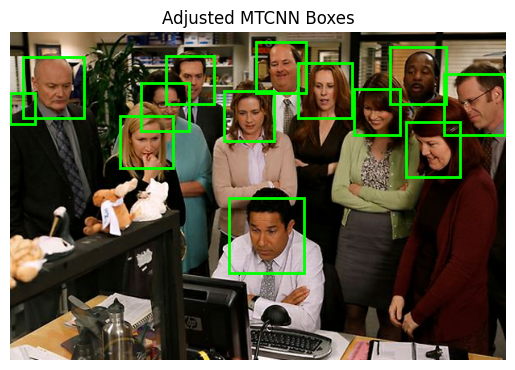

In [81]:
show_image_with_boxes(image/255, result, margin_ratio=0.2)